# 2. Image Enhancement

## Table of Contents
1. [Libraries](#libraries)
2. [Histogram Equalization](#hist)
3. [Denoising with Filters](#denoising)
4. [Challenge](#challenge)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
from skimage import exposure
import skimage
from scipy.ndimage import gaussian_filter as gauss
from scipy.ndimage import median_filter as med
import cv2

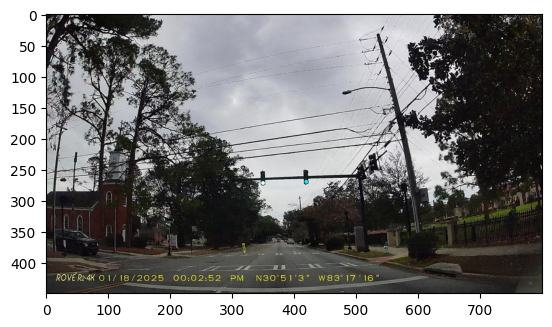

In [2]:
original_image = Image.open('data/image.jpg')
plt.imshow(original_image)
type(original_image)

# Save the image
np.save('data/img.npy', original_image)

#Load the image
original_image = np.load('data/img.npy')

## Histogram Equalization<a class="anchor" id="hist" ></a>

Let's look at the distribution of pixel values in the image. 

Ideally, the image should have relatively even distribution of values, indicating good contrast and making it easier to extract analytical information.

An easy way to check this is to plot a histogram.

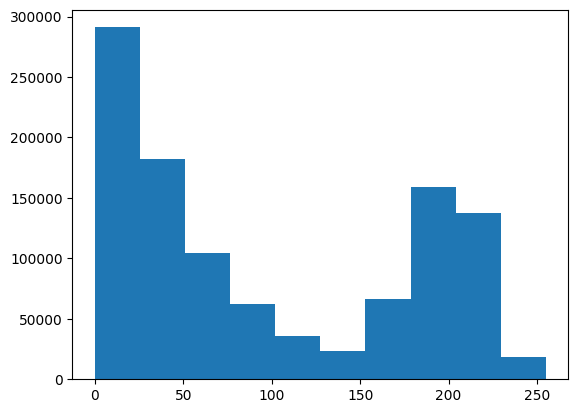

In [3]:
# Plot a histogram - we need to use ravel to "flatten" the 3 dimensions
plt.hist(original_image.ravel())
plt.show()

Another useful way to visualize the statistics of an image is as a cumulative distribution function (CDF) plot. Which shows the cumulative pixel intensity frequencies from 0 to 255.

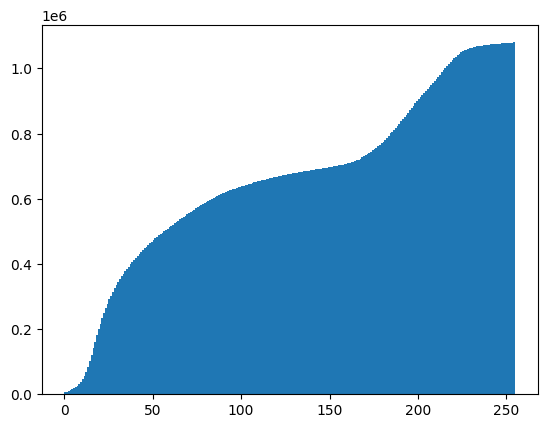

In [4]:
plt.hist(original_image.ravel(), bins=255, cumulative=True)
plt.show()

The histogram and CDF for our image show pretty uneven distribution - there's a lot of contrast in the image. Ideally we should equalize the values in the images we want to analyse to try to make our images more consistent in terms of the shapes they contain irrespective of light levels.

Histogram equalization is often used to improve the statistics of images. In simple terms, the histogram equalization algorithm attempts to adjust the pixel values in the image to create a more uniform distribution. The code in the cell below uses the  **exposure.equalize_hist** method from the **skimage** package to equalize the image.  

C:\Users\diego\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\_shared\utils.py:587: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


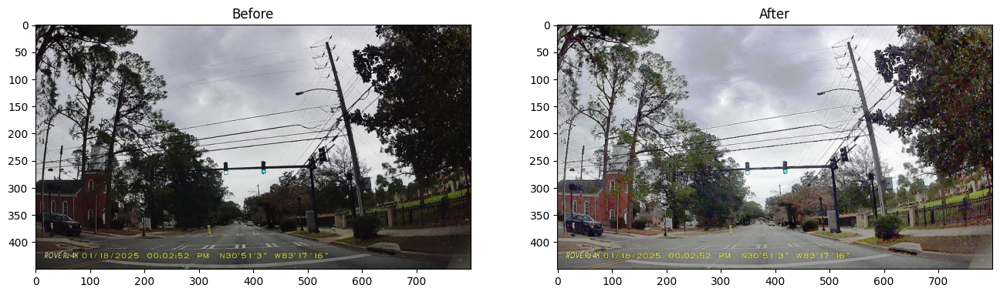

In [5]:
original_image_eq = exposure.equalize_hist(original_image)

fig = plt.figure(figsize=(16, 8))

# Subplot for original image
a=fig.add_subplot(1,2,1)
imgplot = plt.imshow(original_image)
a.set_title('Before')

# Subplot for processed image
a=fig.add_subplot(1,2,2)
imgplot = plt.imshow(original_image_eq)
a.set_title('After')

plt.show()

As with most image operations, there's more than one way to do this. For example, you could also use the **PIL.ImgOps.equalize** method:

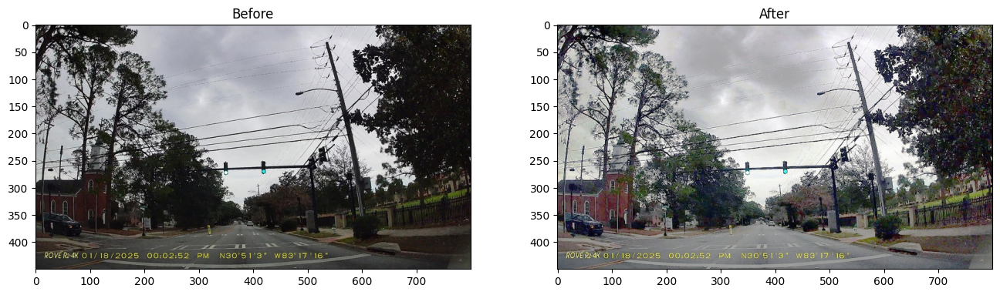

In [6]:

# Equalize the image - but we need to convert the numpy array back to the PIL image format
image_PIL_eq = ImageOps.equalize(Image.fromarray(original_image))

# Display using matplotlib

# Create a figure
fig = plt.figure(figsize=(16, 8))

# Subplot for original image
a=fig.add_subplot(1,2,1)
imgplot = plt.imshow(original_image)
a.set_title('Before')

# Subplot for processed image
a=fig.add_subplot(1,2,2)
imgplot = plt.imshow(image_PIL_eq)
a.set_title('After')

plt.show()

Now let's see what that's done to the histogram and CDF plots:

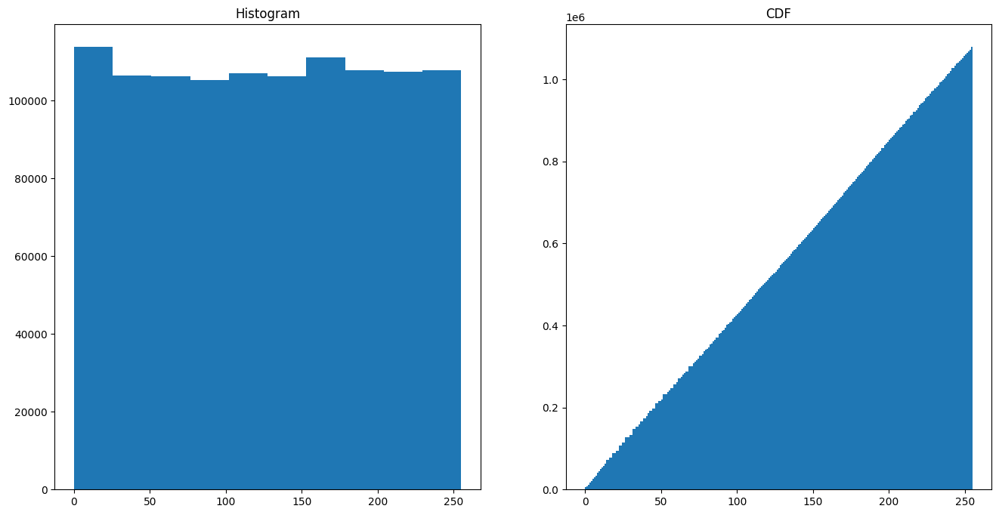

In [7]:
# Display histograms
img_eq = np.array(image_PIL_eq)

# Create a figure
fig = plt.figure(figsize=(16, 8))

# Subplot for original image
a=fig.add_subplot(1,2,1)
imgplot = plt.hist(img_eq.ravel())
a.set_title('Histogram')

# Subplot for processed image
a=fig.add_subplot(1,2,2)
imgplot = plt.hist(img_eq.ravel(), bins=255, cumulative=True)
a.set_title('CDF')

plt.show()

The pixel intensities are more evenly distributed in the equalized image. In particular, the cumulative density shows a straight diagonal cumulation; which is a good sign that the pixel intensity values have been equalized.

## Denoising with Filters <a class="anchor" id="denoising" ></a>

Often images need to be cleaned up to remove "salt and pepper" noise.

### Add Some Random Noise
Let's add some random noise to our image - such as you might see in a photograph taken in low light or at a low resolution.

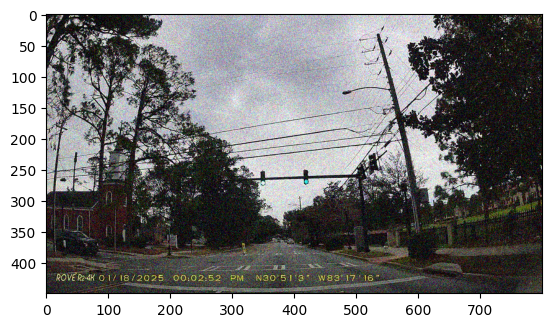

In [8]:
img_n = skimage.util.random_noise(original_image)
plt.imshow(img_n)

### Using a Gaussian Filter
A Gaussian filter applies a weighted average (mean) value for pixels based on the pixels that surround them.

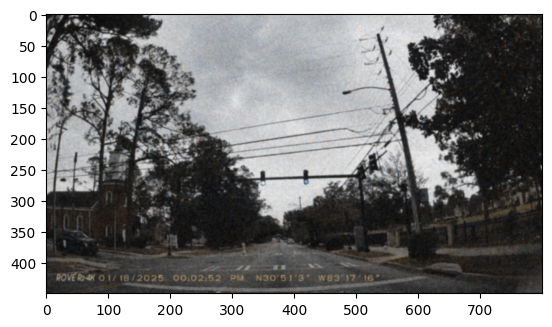

In [9]:
img3_gauss = gauss(img_n, sigma=1)   
plt.imshow(img3_gauss)

### Using a Median Filter
The Gaussian filter results in a blurred image, which may actually be better for feature extraction as it makes it easier to find contrasting areas. If it's too blurred, we could try a median filter, which as the name suggests applies the median value to pixels based on the pixels around them.

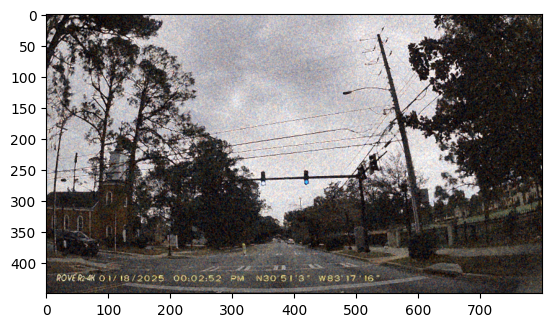

In [10]:
img_med = med(img_n, size=2)
plt.imshow(img_med)

## Challenge <a class="anchor" id="challenge" ></a>

Now, try solving this challenge, you must equalize different windows of the same image in a splitted way.

In [11]:
from PIL import Image

def slice(ruta, n):
    # Equivalente a image_slicer.slice: guarda data/image_FF_CC.png (fila_columna) con n mosaicos en cuadrícula
    im = Image.open(ruta); k = int(n ** 0.5); w, h = im.size
    for f in range(k):
        for c in range(k):
            im.crop((c * w // k, f * h // k, (c + 1) * w // k, (f + 1) * h // k)).save(f'data/image_{f+1:02d}_{c+1:02d}.png')

n = 4
slice('data/image.jpg', n)

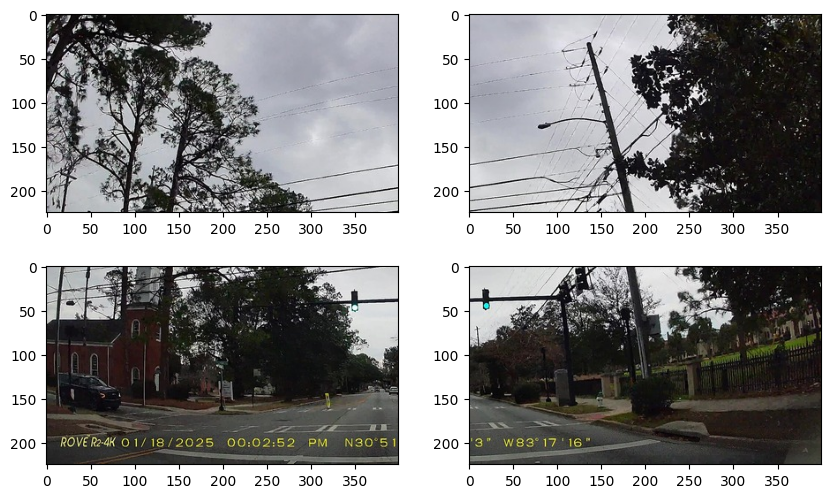

In [12]:
fig = plt.figure(figsize=(10, 6))

plt.subplot(2,2,1)
img = Image.open(f'data/image_01_01.png')
plt.imshow(img)

plt.subplot(2,2,2)
img = Image.open(f'data/image_01_02.png')
plt.imshow(img)

plt.subplot(2,2,3)
img = Image.open(f'data/image_02_01.png')
plt.imshow(img)

plt.subplot(2,2,4)
img = Image.open(f'data/image_02_02.png')
plt.imshow(img)

plt.show()

# Ejercicios de la actividad

Se agregan al notebook base los tres ejercicios solicitados, implementados en Python con OpenCV y scikit-image sobre Google Colab (TIJ Tech Private Limited, 2020). Todos se evalúan con las mismas **métricas**, que se definen primero.

1. [Métricas para comparar métodos de mejora de contraste](#metricas)
2. [Ejercicio 1: ecualización por mosaicos (*tile-based*)](#ej1)
3. [Ejercicio 2: ventana deslizante (SWAHE)](#ej2)
4. [Ejercicio 3: CLAHE](#ej3)
5. [Conclusión](#conclusion)

<a id="metricas"></a>
## Métricas para comparar

No existe una imagen "correcta" con la cual comparar una imagen mejorada, así que se usan medidas de la propia imagen y de su relación con la original:

| Métrica | Definición | Cómo leerla |
|---|---|---|
| Entropía $H$ | $H = -\sum_i p_i \log_2 p_i$ (bits) | Más alta = histograma más repartido; máximo 8 bits |
| Contraste RMS | Desviación estándar de la intensidad | Más alto = más contraste global |
| AMBE | $\lvert \bar{g}_{sal} - \bar{g}_{ent} \rvert$ (error absoluto de brillo medio) | Más bajo = conserva mejor el brillo original |
| Ruido | Media de $\lvert \nabla^2 g \rvert$ (Laplaciano) | Más alto = más textura fina **o** más ruido amplificado |
| Bloques | Salto medio de intensidad en las fronteras de mosaico respecto al salto medio interior | ≈1 = sin costuras; ≫1 = se ven los bloques |

In [13]:
import cv2, numpy as np, matplotlib.pyplot as plt, time
from skimage.filters import rank
from skimage.morphology import disk

def gris(ruta):
    return cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

def entropia(g):
    p = np.bincount(g.ravel(), minlength=256) / g.size
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def metricas(entrada, salida):
    lap = np.abs(cv2.Laplacian(salida.astype(np.float32), cv2.CV_32F))
    return {"H": entropia(salida), "RMS": float(salida.std()), "AMBE": abs(float(salida.mean()) - float(entrada.mean())),
            "Ruido": float(lap.mean())}

def bloques(g, n):
    # cociente entre el salto medio en las fronteras de un mosaico n x n y el salto medio en el resto de la imagen
    g = g.astype(np.float32); H, W = g.shape
    dx = np.abs(np.diff(g, axis=1)); dy = np.abs(np.diff(g, axis=0))
    cx = [round(W * k / n) - 1 for k in range(1, n)]; cy = [round(H * k / n) - 1 for k in range(1, n)]
    borde = np.concatenate([dx[:, cx].ravel(), dy[cy, :].ravel()])
    mask_x = np.ones(dx.shape[1], bool); mask_x[cx] = False
    mask_y = np.ones(dy.shape[0], bool); mask_y[cy] = False
    interior = np.concatenate([dx[:, mask_x].ravel(), dy[mask_y, :].ravel()])
    return float(borde.mean() / interior.mean())

def tabla(nombres, entrada, salidas, extra=None):
    print(f"{'método':34s} {'H (bits)':>9s} {'RMS':>7s} {'AMBE':>7s} {'ruido':>7s}" + (f" {extra[0]:>8s}" if extra else ""))
    for n, s in zip(nombres, salidas):
        m = metricas(entrada, s)
        print(f"{n:34s} {m['H']:9.2f} {m['RMS']:7.1f} {m['AMBE']:7.1f} {m['Ruido']:7.1f}" + (f" {extra[1](s):8.2f}" if extra else ""))

<a id="ej1"></a>
## Ejercicio 1. Ecualización de histograma por mosaicos (*tile-based*)

Investigación. La ecualización global usa un solo histograma para toda la imagen: cada nivel se transforma con la distribución acumulada (CDF) de ese histograma (Htoon, 2020; OpenCV, s. f.), y falla cuando la iluminación no es uniforme. En la versión por mosaicos la imagen se divide en $n \times n$ ventanas
y el histograma de cada ventana se ecualiza por separado (Pizer et al., 1987; Gonzalez & Woods, 2018). Ventanas pequeñas realzan el detalle local, pero cuestan más de administrar y amplifican el ruido; ventanas grandes se parecen al método global.
El inconveniente característico es que dos ventanas vecinas usan transformaciones distintas, y en la frontera aparecen saltos de contraste (efecto de mosaico).

Cómo mejorarlo. La solución de los métodos adaptativos es que cada píxel interpole bilinealmente las transformaciones de los cuatro mosaicos cuyo centro lo rodea, en lugar de usar solo la de su mosaico.
Aquí se implementan las dos versiones para medir la diferencia.

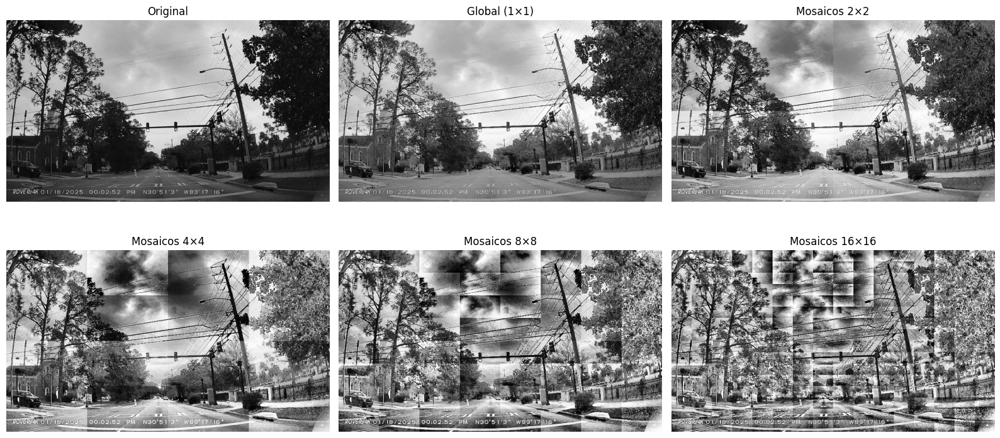

In [14]:
def ecualizar(g):
    return cv2.equalizeHist(g)

def por_mosaicos(g, n):
    # Cada mosaico se ecualiza de forma independiente (sin interpolación)
    H, W = g.shape; out = np.zeros_like(g)
    ys = np.linspace(0, H, n + 1).astype(int); xs = np.linspace(0, W, n + 1).astype(int)
    for i in range(n):
        for j in range(n):
            out[ys[i]:ys[i+1], xs[j]:xs[j+1]] = ecualizar(g[ys[i]:ys[i+1], xs[j]:xs[j+1]])
    return out

def por_mosaicos_interpolado(g, n):
    # Cada píxel mezcla, con pesos bilineales, las 4 LUT de los mosaicos cuyo centro lo rodea (idea de AHE/CLAHE)
    H, W = g.shape
    lut = np.zeros((n, n, 256), np.float32)
    ys = np.linspace(0, H, n + 1).astype(int); xs = np.linspace(0, W, n + 1).astype(int)
    for i in range(n):
        for j in range(n):
            h = np.bincount(g[ys[i]:ys[i+1], xs[j]:xs[j+1]].ravel(), minlength=256).astype(np.float32)
            c = np.cumsum(h); lut[i, j] = 255 * (c - c[0]) / max(c[-1] - c[0], 1)
    cy = (ys[:-1] + ys[1:]) / 2; cx = (xs[:-1] + xs[1:]) / 2         # centros de los mosaicos
    yy, xx = np.mgrid[0:H, 0:W]
    fy = np.clip(np.interp(yy[:, 0], cy, np.arange(n)), 0, n - 1); fx = np.clip(np.interp(xx[0], cx, np.arange(n)), 0, n - 1)
    i0 = np.floor(fy).astype(int); i1 = np.minimum(i0 + 1, n - 1); wy = (fy - i0)[:, None]
    j0 = np.floor(fx).astype(int); j1 = np.minimum(j0 + 1, n - 1); wx = (fx - j0)[None, :]
    v = g.astype(int)
    a = lut[i0[:, None], j0[None, :], v]; b = lut[i0[:, None], j1[None, :], v]
    c_ = lut[i1[:, None], j0[None, :], v]; d = lut[i1[:, None], j1[None, :], v]
    return np.clip((1 - wy) * ((1 - wx) * a + wx * b) + wy * ((1 - wx) * c_ + wx * d), 0, 255).astype(np.uint8)

img = gris("data/image.jpg")
tam = [1, 2, 4, 8, 16]
res = [ecualizar(img)] + [por_mosaicos(img, n) for n in tam[1:]]
fig, ejes = plt.subplots(2, 3, figsize=(16, 8))
for a, im, t in zip(ejes.ravel(), [img] + res[:5], ["Original", "Global (1×1)"] + [f"Mosaicos {n}×{n}" for n in tam[1:5]]):
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

Sin interpolar:
método                              H (bits)     RMS    AMBE   ruido
original                                7.48    78.8     0.0    44.8
global                                  7.23    73.6    29.5    55.8
mosaicos 2x2                            7.70    73.6    29.8    66.5
mosaicos 4x4                            7.86    73.6    30.5    85.0
mosaicos 8x8                            7.95    73.5    31.4   105.1
mosaicos 16x16                          7.97    73.7    32.6   124.8

Índice de bloques (≈1 = sin costuras):
   n  sin interpolar  interpolado
   2            1.59         1.06
   4            1.67         1.05
   8            1.64         1.01
  16            1.51         1.00


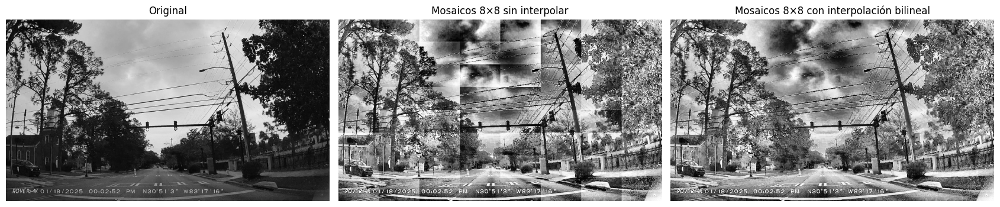

In [15]:
# Tamaño de ventana vs. calidad: los mosaicos sin interpolar producen costuras; la interpolación bilineal las elimina
print("Sin interpolar:")
tabla(["original", "global"] + [f"mosaicos {n}x{n}" for n in tam[1:]], img, [img] + res)
sin = {n: por_mosaicos(img, n) for n in tam[1:]}
con = {n: por_mosaicos_interpolado(img, n) for n in tam[1:]}
print("\nÍndice de bloques (≈1 = sin costuras):")
print(f"{'n':>4s} {'sin interpolar':>15s} {'interpolado':>12s}")
for n in tam[1:]:
    print(f"{n:4d} {bloques(sin[n], n):15.2f} {bloques(con[n], n):12.2f}")

n = 8
fig, ejes = plt.subplots(1, 3, figsize=(17, 5.2))
for a, im, t in zip(ejes, (img, sin[n], con[n]), ("Original", f"Mosaicos {n}×{n} sin interpolar", f"Mosaicos {n}×{n} con interpolación bilineal")):
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

**Resultados y discusión.**
- En esta imagen la ecualización global no mejora las métricas: la entropía baja (7.48 → 7.23 bits) y el contraste RMS también (78.8 → 73.6), porque el histograma original ya ocupa casi todo el rango y solo se redistribuye. Al reducir la ventana el detalle local aumenta (la entropía sube de 7.70 a 7.97 bits y el ruido de 67 a 125 entre 2×2 y 16×16) y el brillo medio se aleja del original (AMBE de 29.8 a 32.6).
- Sin interpolación aparecen costuras visibles en las fronteras entre mosaicos; el índice de bloques lo confirma (1.5–1.7 según el número de mosaicos) y la versión interpolada lo reduce a 1.00–1.06, es decir, sin costuras medibles.
- Existe un compromiso entre tamaño de ventana y costo: con $n\times n$ mosaicos hay que calcular $n^2$ histogramas y (si se interpola) mezclar cuatro tablas por píxel, aunque cada tabla se calcula una sola vez y el costo total por píxel sigue siendo constante.
- Respuesta a la pregunta de la actividad. Las diferencias de contraste entre bloques se reducen (1) interpolando bilinealmente las transformaciones de mosaicos vecinos, (2) limitando el contraste de cada histograma (CLAHE, ejercicio 3) y (3) usando ventanas que se solapan (ejercicio 2).

<a id="ej2"></a>
## Ejercicio 2. Ecualización adaptativa con ventana deslizante (SWAHE)

Investigación. En SWAHE (*sliding window adaptive histogram equalization*) se calcula un histograma para cada píxel, con los píxeles de la ventana centrada en él, y se transforma solo el píxel central con la función de distribución acumulada de esa ventana
(Pizer et al., 1987). Como cada píxel tiene su propia ventana no hay costuras, pero es lo más costoso: $O(N\cdot w^2)$ para una imagen de $N$ píxeles y ventana $w\times w$ si se hace ingenuamente.
Para el píxel central $v$ de la ventana, la salida es $s = 255\cdot \frac{\#\{\text{píxeles de la ventana} \le v\}}{w^2}$, es decir, el rango percentil del píxel dentro de su vecindad.

Se implementa la versión directa con NumPy y se valida contra la ecualización local de scikit-image (`rank.equalize`), que usa histogramas actualizados de forma incremental.

In [16]:
from numpy.lib.stride_tricks import sliding_window_view

def swahe(g, w):
    # Versión directa: rango percentil de cada píxel dentro de su ventana w x w (bordes reflejados)
    r = w // 2
    p = np.pad(g, r, mode="reflect")
    ventanas = sliding_window_view(p, (w, w))                         # (H, W, w, w)
    rango = (ventanas <= g[..., None, None]).sum(axis=(-1, -2))
    return np.clip(255.0 * rango / (w * w), 0, 255).astype(np.uint8)

chica = cv2.resize(gris("data/image.jpg"), (256, 144), interpolation=cv2.INTER_AREA)
for w in (15, 31, 63):
    t0 = time.perf_counter(); s = swahe(chica, w); t_np = time.perf_counter() - t0
    t0 = time.perf_counter(); ref = rank.equalize(chica, footprint=np.ones((w, w), bool)); t_sk = time.perf_counter() - t0
    dif = np.abs(s.astype(int) - ref.astype(int))
    print(f"ventana {w:2d}x{w:2d}: NumPy directo {t_np*1000:7.1f} ms | scikit-image {t_sk*1000:6.1f} ms | diferencia media {dif.mean():.2f} niveles, máxima {dif.max()}")

ventana 15x15: NumPy directo    10.9 ms | scikit-image    2.1 ms | diferencia media 0.77 niveles, máxima 30
ventana 31x31: NumPy directo    31.0 ms | scikit-image    3.3 ms | diferencia media 1.38 niveles, máxima 27
ventana 63x63: NumPy directo   115.3 ms | scikit-image    5.5 ms | diferencia media 2.93 niveles, máxima 32


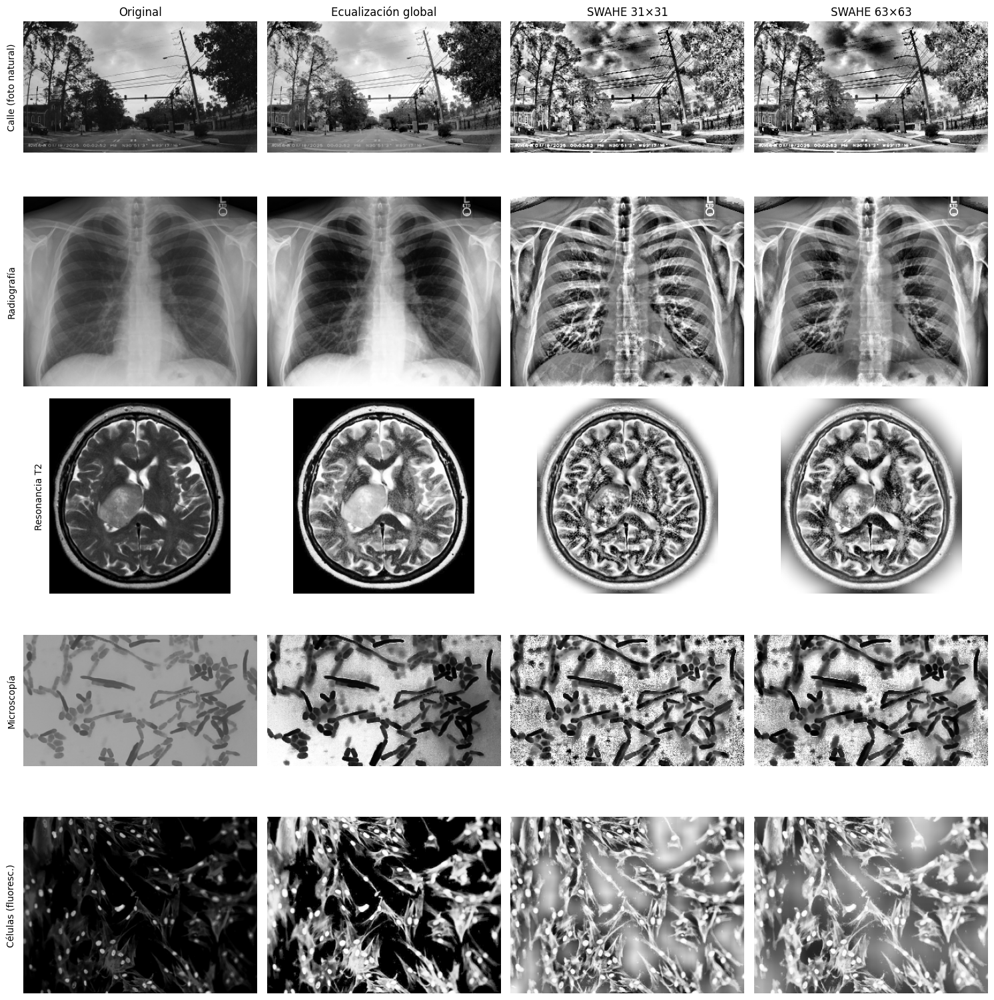


Calle (foto natural)
método                              H (bits)     RMS    AMBE   ruido
original                                7.40    74.3     0.0    39.1
global                                  7.21    73.1    30.2    45.4
SWAHE 31                                7.95    66.6    32.4    96.2
SWAHE 63                                7.96    67.5    31.3    79.3

Radiografía
método                              H (bits)     RMS    AMBE   ruido
original                                7.43    47.6     0.0     5.4
global                                  7.34    73.6    15.7     8.8
SWAHE 31                                7.74    54.9    18.3    33.0
SWAHE 63                                7.76    56.2    16.6    20.8

Resonancia T2
método                              H (bits)     RMS    AMBE   ruido
original                                6.22    54.2     0.0    11.1
global                                  6.03    84.4    40.1    21.6
SWAHE 31                                7.59    72.9 

In [17]:
# Comparación con distintos tipos de imagen
conjunto = {"Calle (foto natural)": "data/image.jpg", "Radiografía": "data/radiografia.jpg", "Resonancia T2": "data/resonancia_t2.jpg",
            "Microscopía": "data/microscopia.jpg", "Células (fluoresc.)": "data/celulas.jpg"}
fig, ejes = plt.subplots(len(conjunto), 4, figsize=(15, 3.1 * len(conjunto)))
filas_tab = []
for r, (nombre, ruta) in enumerate(conjunto.items()):
    g = gris(ruta); g = cv2.resize(g, (320, round(g.shape[0] * 320 / g.shape[1])), interpolation=cv2.INTER_AREA)
    outs = [g, ecualizar(g), swahe(g, 31), swahe(g, 63)]
    for c, (im, t) in enumerate(zip(outs, ("Original", "Ecualización global", "SWAHE 31×31", "SWAHE 63×63"))):
        ejes[r, c].imshow(im, cmap="gray", vmin=0, vmax=255); ejes[r, c].axis("off")
        if r == 0: ejes[r, c].set_title(t)
    ejes[r, 0].text(-.03, .5, nombre, transform=ejes[r, 0].transAxes, rotation=90, ha="right", va="center")
    filas_tab.append((nombre, outs))
plt.tight_layout(); plt.show()
for nombre, outs in filas_tab:
    print(f"\n{nombre}")
    tabla(["original", "global", "SWAHE 31", "SWAHE 63"], outs[0], outs)

**Resultados y discusión.**
- La implementación directa coincide con `rank.equalize` (diferencia media de 0.8 a 2.9 niveles; el máximo, cercano a 30, aparece en píxeles con empates o en los bordes reflejados), pero es entre 5 y 20 veces más lenta y su costo crece con el área de la ventana, mientras que scikit-image actualiza el histograma al deslizar.
- Sin costuras y con máximo detalle local, pero SWAHE amplifica el ruido en zonas casi uniformes: cuando toda la ventana es casi plana, cualquier variación mínima se estira a todo el rango. La métrica de ruido lo confirma (en la calle pasa de 39 a 96 con la ventana de 31) y, en las imágenes de fondo casi negro (células y resonancia), ese fondo se convierte en gris medio: el AMBE se dispara a 100–133 niveles.
- Con la ventana de 31 el efecto es más fuerte que con la de 63 en las cinco imágenes (el ruido baja al ampliar la ventana). En la resonancia, de fondo homogéneo, el resultado es demasiado agresivo (AMBE de 100): por eso los métodos médicos limitan el contraste (CLAHE).
- En la microscopía el ruido casi se multiplica por 10 (de 9 a 86 con la ventana de 31) aunque la entropía sube de 5.8 a 7.95 bits: más "información" en el histograma no siempre es más información útil.

<a id="ej3"></a>
## Ejercicio 3. CLAHE (*Contrast Limited Adaptive Histogram Equalization*)

Investigación. CLAHE combina dos ideas: (1) ecualización por mosaicos con interpolación bilineal entre mosaicos vecinos (evita las costuras del ejercicio 1) y (2) recorte del histograma: antes de calcular la
distribución acumulada, cada barra del histograma que supera un umbral (*clip limit*) se recorta y el exceso se reparte de forma uniforme entre todos los niveles (Zuiderveld, 1994). Como la pendiente de la función de transformación es proporcional a la altura del histograma,
recortarlo limita la ganancia de contraste y, con ella, la amplificación del ruido en zonas homogéneas. Es uno de los métodos estándar en imagen médica (Pizer et al., 1987) y en visión general.
Parámetros: `clipLimit` (mayor = más contraste y más ruido) y `tileGridSize` (tamaño de la cuadrícula de mosaicos). Se usa la implementación de OpenCV (Bradski, 2000).

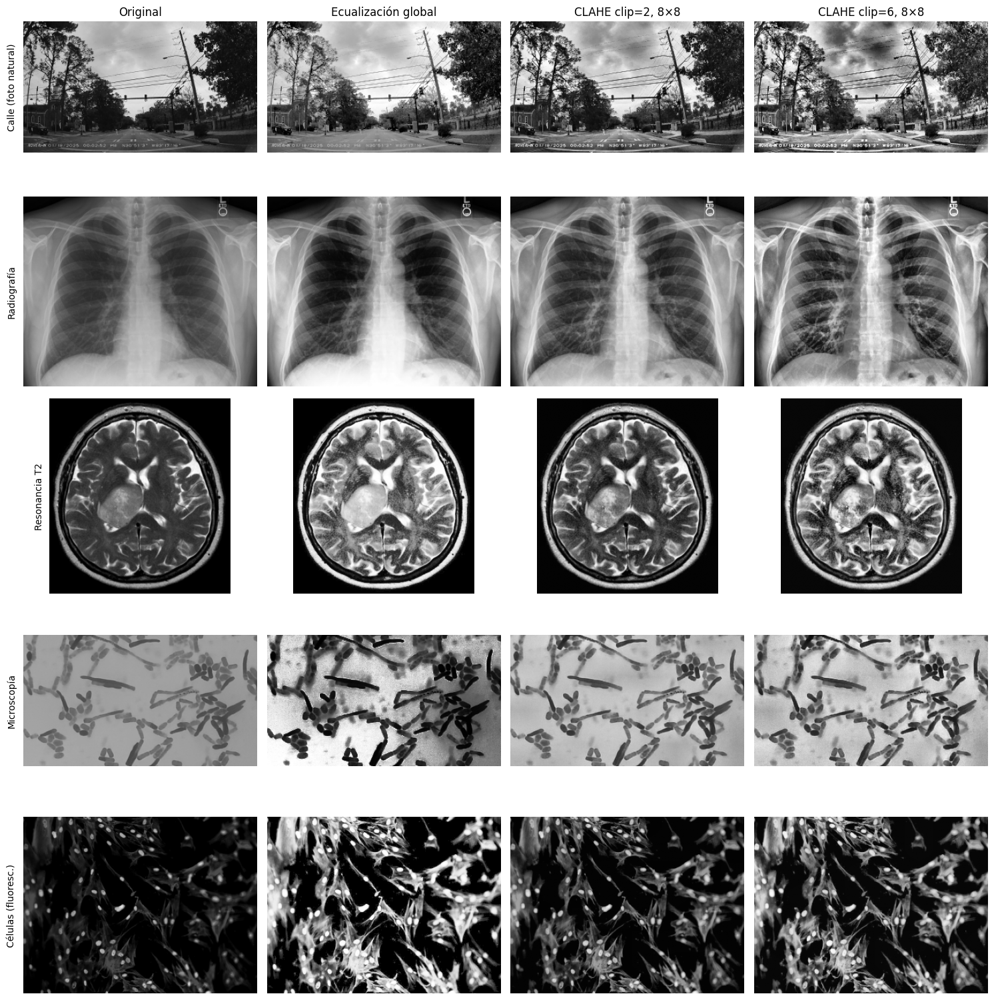


Calle (foto natural)
método                              H (bits)     RMS    AMBE   ruido
original                                7.40    74.3     0.0    39.1
global                                  7.21    73.1    30.2    45.4
CLAHE clip=2                            7.82    73.1    14.8    56.3
CLAHE clip=6                            7.93    67.0    23.1    70.8

Radiografía
método                              H (bits)     RMS    AMBE   ruido
original                                7.43    47.6     0.0     5.4
global                                  7.34    73.6    15.7     8.8
CLAHE clip=2                            7.69    55.9    11.8    11.0
CLAHE clip=6                            7.82    58.1    16.4    17.8

Resonancia T2
método                              H (bits)     RMS    AMBE   ruido
original                                6.22    54.2     0.0    11.1
global                                  6.03    84.4    40.1    21.6
CLAHE clip=2                            6.75    67.4 

In [18]:
def clahe(g, clip=2.0, grid=8):
    return cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid)).apply(g)

fig, ejes = plt.subplots(len(conjunto), 4, figsize=(15, 3.1 * len(conjunto)))
todas = []
for r, (nombre, ruta) in enumerate(conjunto.items()):
    g = gris(ruta); g = cv2.resize(g, (320, round(g.shape[0] * 320 / g.shape[1])), interpolation=cv2.INTER_AREA)
    outs = [g, ecualizar(g), clahe(g, 2.0, 8), clahe(g, 6.0, 8)]
    for c, (im, t) in enumerate(zip(outs, ("Original", "Ecualización global", "CLAHE clip=2, 8×8", "CLAHE clip=6, 8×8"))):
        ejes[r, c].imshow(im, cmap="gray", vmin=0, vmax=255); ejes[r, c].axis("off")
        if r == 0: ejes[r, c].set_title(t)
    ejes[r, 0].text(-.03, .5, nombre, transform=ejes[r, 0].transAxes, rotation=90, ha="right", va="center")
    todas.append((nombre, outs))
plt.tight_layout(); plt.show()
for nombre, outs in todas:
    print(f"\n{nombre}")
    tabla(["original", "global", "CLAHE clip=2", "CLAHE clip=6"], outs[0], outs)

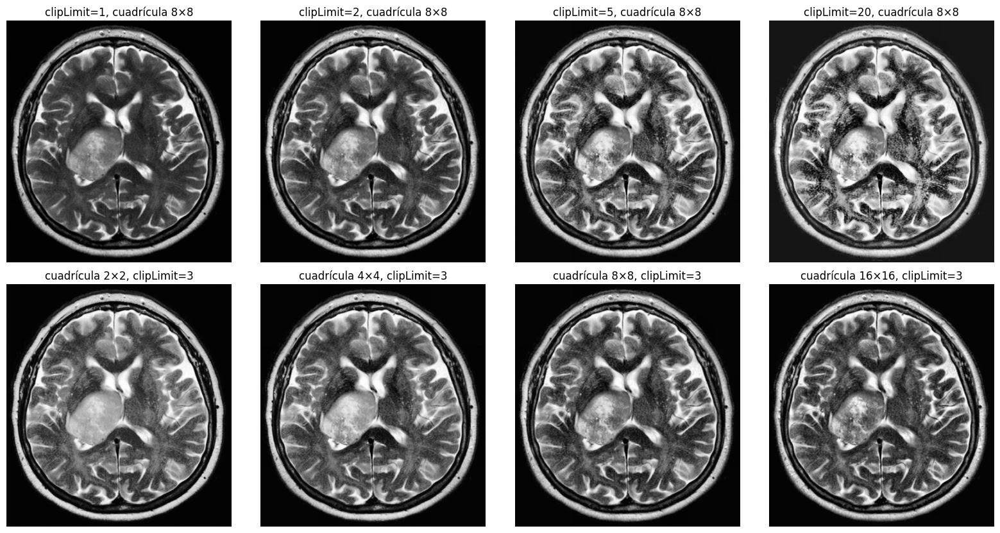


Ruido (Laplaciano medio) según clipLimit, cuadrícula 8×8:
  clipLimit= 1: 8.3   RMS=62.2
  clipLimit= 2: 10.0   RMS=67.2
  clipLimit= 5: 13.4   RMS=74.4
  clipLimit=20: 16.0   RMS=75.3
  global      : 13.9   RMS=84.6


In [19]:
# Efecto de los dos parámetros sobre la resonancia: clipLimit y tamaño de la cuadrícula
g = gris("data/resonancia_t2.jpg")
fig, ejes = plt.subplots(2, 4, figsize=(16, 8.4))
clips = [1, 2, 5, 20]
for c, cl in enumerate(clips):
    ejes[0, c].imshow(clahe(g, cl, 8), cmap="gray", vmin=0, vmax=255); ejes[0, c].set_title(f"clipLimit={cl}, cuadrícula 8×8"); ejes[0, c].axis("off")
grids = [2, 4, 8, 16]
for c, gr in enumerate(grids):
    ejes[1, c].imshow(clahe(g, 3, gr), cmap="gray", vmin=0, vmax=255); ejes[1, c].set_title(f"cuadrícula {gr}×{gr}, clipLimit=3"); ejes[1, c].axis("off")
plt.tight_layout(); plt.show()
print("\nRuido (Laplaciano medio) según clipLimit, cuadrícula 8×8:")
for cl in clips: print(f"  clipLimit={cl:2d}: {metricas(g, clahe(g, cl, 8))['Ruido']:.1f}   RMS={clahe(g, cl, 8).std():.1f}")
print(f"  global      : {metricas(g, ecualizar(g))['Ruido']:.1f}   RMS={ecualizar(g).std():.1f}")

**Resultados y discusión.**
- CLAHE conserva el detalle local sin las costuras del ejercicio 1 y con menos ruido que el ejercicio 2: en la radiografía el contraste global sube (RMS de 47.6 a 55.9) con un ruido de 11.0, frente a 33.0 de SWAHE con ventana de 31.
- La ecualización global es un buen punto de partida cuando la iluminación es homogénea, pero en imágenes con fondo negro amplio (células, resonancia) le asigna demasiados niveles al fondo: en las células cambia el brillo medio en 62 niveles y la entropía baja (4.97 → 4.84 bits), mientras que CLAHE con clip=2 la sube a 5.84 con un cambio de brillo de 22.
- El clipLimit controla el compromiso: en la resonancia, subirlo de 1 a 20 eleva el ruido de 8.3 a 16.0 y el contraste RMS de 62 a 75; los valores altos se acercan al comportamiento de SWAHE. La cuadrícula controla la escala del detalle: con pocas celdas (2×2) el resultado tiende al método global y con muchas (16×16) se realzan texturas más finas.
- Para imagen médica y para preprocesar antes de detectores (bordes, keypoints, redes), CLAHE con `clipLimit≈2–3` y cuadrícula 8×8 es un valor razonable de partida.

<a id="conclusion"></a>
## Conclusión

| Método | Costuras | Ruido | Costo | Cuándo usarlo |
|---|---|---|---|---|
| Ecualización global | No | Bajo | Mínimo | Iluminación homogénea, ajuste rápido |
| Mosaicos sin interpolar | Sí | Medio | $n^2$ histogramas | Solo como paso didáctico |
| Mosaicos interpolados | No | Medio | Medio | Fotografía con iluminación desigual |
| SWAHE | No | Alto | Alto | Máximo detalle local si el ruido no importa |
| CLAHE | No | Controlado | Medio | Uso general y médico |

- Los métodos adaptativos resuelven el problema de la iluminación desigual usando estadística local; el precio es el ruido y el costo, y las mejoras del ejercicio 1 (interpolar) y del 3 (recortar) atacan cada uno de esos problemas.
- Ninguna métrica sola decide qué método es mejor: la entropía y el contraste premian la mejora, mientras que el AMBE y el ruido penalizan los excesos. Hay que leerlas juntas.
- Dos correcciones necesarias en el notebook base para que funcione con versiones actuales: `scipy.ndimage.filters` ya no existe (se usa `scipy.ndimage`) y el paquete `image_slicer` se reemplazó por un recorte con Pillow (produce los mismos cuatro archivos).

## Referencias

- Bradski, G. (2000). The OpenCV library [La biblioteca OpenCV]. *Dr. Dobb's Journal of Software Tools, 25*(11), 120–123.
- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* [Procesamiento digital de imágenes] (4.ª ed.). Pearson. (Cap. 3 y 9.)
- Htoon, K. S. (2020, 18 de agosto). *A tutorial to histogram equalization* [Tutorial de ecualización de histograma]. Medium. https://medium.com/@kyawsawhtoon/a-tutorial-to-histogram-equalization-497600f270e2
- OpenCV. (s. f.). *Histogram equalization* [Ecualización de histograma; tutorial]. https://docs.opencv.org/3.4/d4/d1b/tutorial_histogram_equalization.html
- Pizer, S. M., Amburn, E. P., Austin, J. D., Cromartie, R., Geselowitz, A., Greer, T., ter Haar Romeny, B., Zimmerman, J. B., & Zuiderveld, K. (1987). Adaptive histogram equalization and its variations [La ecualización adaptativa de histograma y sus variantes]. *Computer Vision, Graphics, and Image Processing, 39*(3), 355–368. https://doi.org/10.1016/S0734-189X(87)80186-X
- TIJ Tech Private Limited. (2020, 15 de diciembre). *Introduction to image processing using OpenCV in Google Colab* [Introducción al procesamiento de imágenes con OpenCV en Google Colab]. Medium. https://karmatnspyphuntsho-tijtech.medium.com/introduction-to-image-processing-using-opencv-in-google-colab-a449306cb395
- van der Walt, S., Schönberger, J. L., Nunez-Iglesias, J., Boulogne, F., Warner, J. D., Yager, N., Gouillart, E., & Yu, T. (2014). scikit-image: Image processing in Python [scikit-image: procesamiento de imágenes en Python]. *PeerJ, 2*, e453. https://doi.org/10.7717/peerj.453
- Zuiderveld, K. (1994). Contrast limited adaptive histogram equalization [Ecualización adaptativa de histograma con contraste limitado]. En P. S. Heckbert (Ed.), *Graphics gems IV* (pp. 474–485). Academic Press.
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons; CC0 y CC BY-SA).

## Declaración y uso de IA

Para la elaboración de este trabajo se utilizó Claude Opus, de Anthropic, como herramienta de apoyo en el desarrollo y la revisión del código, así como en la redacción del documento final. Su uso fue complementario y no sustituyó el criterio académico de los autores. El análisis, la interpretación de los resultados y la formulación de las conclusiones corresponden a los autores, quienes asumen la responsabilidad íntegra sobre la revisión, la exactitud y la integridad académica del contenido final.